# How to Build Passing Networks   

**Competition Focus:** La Liga - 2015/16 Season  
**Dataset:** StatsBomb Open Data (free event data repository)  
**Purpose:** Build passing network visualisations that reveal team structure and playing style, using event data to analyse interactions between players and how possession is organised on the pitch.  
**Methods:** Feature engineering, network construction, spatial alignment across matches, and aggregation of player interactions into a season-level network.  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  
**Medium Articles:**  
_Coming soon_

**Notebook first written:** `13/05/2026`  
**Last updated:** `13/05/2026`  

> This notebook presents a step-by-step approach to building passing networks using event data from the 2015/16 La Liga season. Passes between players are aggregated to construct networks where nodes represent players’ average on-ball positions and edges reflect passing interactions.  
>
> To ensure consistency across matches, player positions are spatially aligned before aggregation, allowing a stable representation of team structure despite rotations and tactical variation.  
>
> Match-level networks are combined into a single season-level network, where node positions reflect average spatial roles and edges capture overall passing tendencies across the season.  
>
> The objective is not to evaluate performance, but to demonstrate how network-based visualisation techniques can be used to better understand and communicate patterns in football data.  

---------------------

## 1. Packages and Configuration

In [2]:
# Standard library
import math
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Football data||
from statsbombpy import sb

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Utilities
from tqdm import tqdm

warnings.filterwarnings("ignore", message="credentials were not supplied")

## Check Bundesliga

In [8]:
import pandas as pd
from statsbombpy import sb

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ------------------------------------------------------------
# 1. LOAD ALL COMPETITIONS
# ------------------------------------------------------------
free_comps = sb.competitions()

# Keep only men's competitions
comps = free_comps[
    free_comps["competition_gender"] == "male"
].copy()

# Extract season start year
comps["season_start"] = (
    comps["season_name"]
    .str.split("/")
    .str[0]
    .astype(int)
)

# Keep only seasons >= 2015
comps = comps[comps["season_start"] >= 2015].copy()


# ------------------------------------------------------------
# 2. COUNT MATCHES PER COMPETITION + SEASON
# ------------------------------------------------------------
match_counts = []

for comp_id, season_id in zip(comps["competition_id"], comps["season_id"]):
    
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        "competition_id": comp_id,
        "season_id": season_id,
        "matches_count": matches_count
    })

match_counts_df = pd.DataFrame(match_counts)


# ------------------------------------------------------------
# 3. MERGE METADATA
# ------------------------------------------------------------
metadata_cols = [
    "competition_id",
    "season_id",
    "competition_name",
    "season_name",
    "country_name"
]

match_counts_df = match_counts_df.merge(
    comps[metadata_cols],
    on=["competition_id", "season_id"],
    how="left"
)


# ------------------------------------------------------------
# 4. KEEP "FULL" DATASETS ONLY
# (threshold: tweak if needed)
# ------------------------------------------------------------
FULL_MATCH_THRESHOLD = 100  # leagues ~300+, cups smaller

full_comps = match_counts_df[
    match_counts_df["matches_count"] >= FULL_MATCH_THRESHOLD
].copy()


# ------------------------------------------------------------
# 5. SORT & VIEW
# ------------------------------------------------------------
full_comps = full_comps.sort_values(
    "matches_count",
    ascending=False
).reset_index(drop=True)

full_comps

,competition_id,season_id,matches_count,competition_name,season_name,country_name
0,11,27,380,La Liga,2015/2016,Spain
1,2,27,380,Premier League,2015/2016,England
2,12,27,380,Serie A,2015/2016,Italy
3,7,27,377,Ligue 1,2015/2016,France
4,9,27,306,1. Bundesliga,2015/2016,Germany
5,1238,108,115,Indian Super league,2021/2022,India


## 2. Load Competition, Match & Event Data

In [10]:
comp = 9
season = 27

# Download Matches
matches_df = sb.matches(
    competition_id=comp,
    season_id=season
)

len(matches_df)

306

In [11]:
matches_df.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3890561,2016-05-14,15:30:00.000,Germany - 1. Bundesliga,2015/2016,Hoffenheim,Schalke 04,1,4,available,unscheduled,2023-07-24T07:47:12.510532,None,34,Regular Season,PreZero Arena,Felix Brych,Julian Nagelsmann,André Breitenreiter,1.1.0,2,2
1,3890505,2016-04-02,15:30:00.000,Germany - 1. Bundesliga,2015/2016,Bayern Munich,Eintracht Frankfurt,1,0,available,unscheduled,2023-08-03T13:14:14.503553,None,28,Regular Season,Allianz Arena,Florian Meyer,Josep Guardiola i Sala,Niko Kovač,1.1.0,2,2
2,3890511,2016-04-08,20:30:00.000,Germany - 1. Bundesliga,2015/2016,Hertha Berlin,Hannover 96,2,2,available,unscheduled,2023-08-06T05:50:38.345688,None,29,Regular Season,Olympiastadion Berlin,Benjamin Brand,Pál Dárdai,Daniel Stendel,1.1.0,2,2
3,3890515,2016-04-09,15:30:00.000,Germany - 1. Bundesliga,2015/2016,Hamburger SV,Darmstadt 98,1,2,available,unscheduled,2023-07-18T17:52:17.363623,None,29,Regular Season,Volksparkstadion,Peter Sippel,Bruno Labbadia,Dirk Schuster,1.1.0,2,2
4,3890411,2015-12-20,16:30:00.000,Germany - 1. Bundesliga,2015/2016,Hertha Berlin,FSV Mainz 05,2,0,available,unscheduled,2023-07-16T13:47:06.565811,None,17,Regular Season,Olympiastadion Berlin,Peter Sippel,Pál Dárdai,Martin Schmidt,1.1.0,2,2


In [12]:
from tqdm import tqdm
import pandas as pd
from statsbombpy import sb

all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    
    events = sb.events(match_id=match_id)
    
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 306/306 [08:18<00:00,  1.63s/it]


In [13]:
matches_meta = matches_df[[
    "match_id",
    "season",
    "competition",
    "home_team",
    "away_team"
]].copy()

passes_df = passes_df.merge(matches_meta, on="match_id", how="left")

In [14]:
len(passes_df)

295599

In [15]:
passes_df.to_csv("Datasets/passes_bundesliga_201516_statsbomb_all.csv", index=False)

In [3]:
passes_df = pd.read_csv("Datasets/passes_bundesliga_201516_statsbomb_all.csv")

C:\Users\vicky\AppData\Local\Temp\ipykernel_27092\1488042079.py:1: DtypeWarning: Columns (33,40,91,92,99) have mixed types. Specify dtype option on import or set low_memory=False.
  passes_df = pd.read_csv("Datasets/passes_bundesliga_201516_statsbomb_all.csv")


## 3. Data Cleaning & Feature Engineering

In [5]:
passes = passes_df.copy()

def extract_coords(col):
    x = pd.to_numeric(col.astype(str).str.strip("[]").str.split().str[0], errors="coerce")
    y = pd.to_numeric(col.astype(str).str.strip("[]").str.split().str[1], errors="coerce")
    return x, y

passes["start_x"], passes["start_y"] = extract_coords(passes["location"])
passes["end_x"], passes["end_y"] = extract_coords(passes["pass_end_location"])

FEATURES = ["start_x", "start_y", "end_x", "end_y"]

# Remove unwanted passes
passes = passes[passes["pass_outcome"] != "Injury Clearance"].copy()

# Fix pitch bounds

for col, max_val in [("start_x", 120), ("end_x", 120), ("start_y", 80), ("end_y", 80)]:
    passes[col] = passes[col].clip(lower=0, upper=max_val)

In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None )

passes.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,injury_stoppage_in_chain,miscontrol_aerial_won,pass_no_touch,pass_straight,block_offensive,foul_committed_type,foul_committed_offensive,shot_deflected,clearance_other,goalkeeper_success_out,pass_miscommunication,dribble_no_touch,foul_committed_penalty,foul_won_penalty,shot_open_goal,block_save_block,goalkeeper_punched_out,shot_redirect,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_shot_saved_to_post,shot_saved_to_post,goalkeeper_lost_out,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,season,competition,home_team,away_team,start_x,start_y,end_x,end_y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.453238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,644e16d7-10ca-45f0-8128-fc0055d6f753,5,NaN,"[61.0, 40.1]",3890561,0,NaN,NaN,NaN,-1.919567,NaN,Left Foot,NaN,NaN,NaN,"[60.2, 37.9]",NaN,Ground Pass,NaN,2.340940,NaN,NaN,Andrej Kramarić,5460.0,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Mark Uth,8387.0,Right Attacking Midfield,2,Hoffenheim,175,['7602c8d9-d988-4eae-bb9f-309fbad4c7c5'],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hoffenheim,175,00:00:00.482,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015/2016,Germany - 1. Bundesliga,Hoffenheim,Schalke 04,NaN,40.1,NaN,37.9
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.151865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77e2ddaf-6de3-49e7-a318-7d765799b543,8,NaN,"[59.4, 38.3]",3890561,0,NaN,NaN,NaN,2.536994,NaN,Left Foot,NaN,NaN,NaN,"[53.9, 42.1]",NaN,Ground Pass,NaN,6.685058,NaN,NaN,Sebastian Rudy,6039.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Andrej Kramarić,5460.0,Center Forward,2,Hoffenheim,175,['69e3b0a7-5847-40db-91d5-0e24fb150f63'],1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hoffenheim,175,00:00:01.015,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015/2016,Germany - 1. Bundesliga,Hoffenheim,Schalke 04,NaN,38.3,NaN,42.1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.389406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2c51f271-c812-45af-896b-06f49a14a5bb,11,NaN,"[52.3, 45.2]",3890561,0,NaN,NaN,NaN,2.390664,NaN,Right Foot,NaN,NaN,NaN,"[34.3, 62.0]",NaN,Ground Pass,NaN,24.621940,NaN,NaN,Fabian Lukas Schär,5537.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Sebastian Rudy,6039.0,Left Defensive Midfield,2,Hoffenheim,175,['c30d7035-bb00-4012-9b06-2f3135cdf4d6'],2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hoffenheim,175,00:00:02.954,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

# Passing Networks

In [15]:
import pandas as pd
from collections import Counter
from statsbombpy import sb

# ------------------------------------------------------------
# LOAD MATCHES
# ------------------------------------------------------------
competitions = sb.competitions()

laliga = competitions[
    (competitions["competition_name"] == "La Liga") &
    (competitions["competition_gender"] == "male")
]

leagues = list(zip(laliga["competition_id"], laliga["season_id"]))

matches = pd.concat(
    [sb.matches(comp, season) for comp, season in leagues],
    ignore_index=True
)

barca_matches = matches[
    (matches["home_team"] == "Barcelona") |
    (matches["away_team"] == "Barcelona")
].copy()


# ------------------------------------------------------------
# STARTING XI FUNCTION
# ------------------------------------------------------------
def get_starting_xi(match_id: int, team: str):

    lineup = sb.lineups(match_id=match_id)[team].copy()

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    starters = df[df["start_reason"] == "Starting XI"].copy()

    starters["player_full"] = starters["player_name"].str.strip()

    starters["player"] = (
        starters["player_nickname"]
        .fillna(starters["player_name"])
        .str.strip()
    )

    return starters[["player", "player_full", "position"]]

In [16]:
def build_player_position_counts(matches_df):

    rows = []

    seasons = matches_df["season"].unique()

    for season in seasons:

        print(f"\n📅 Processing {season}")

        season_matches = matches_df[
            matches_df["season"] == season
        ]

        player_position_counts = Counter()
        player_full_map = {}

        for match_id in season_matches["match_id"]:

            try:
                xi = get_starting_xi(match_id, "Barcelona")

                for _, row in xi.iterrows():

                    key = (row["player"], row["position"])
                    player_position_counts[key] += 1

                    player_full_map[row["player"]] = row["player_full"]

            except:
                continue

        # convert to dataframe
        for (player, pos), count in player_position_counts.items():

            rows.append({
                "season": season,
                "player": player,
                "player_full": player_full_map[player],
                "position": pos,
                "appearances": count
            })

    return pd.DataFrame(rows)

In [17]:
player_position_df = pd.read_csv("Datasets/barca_player_position_counts.csv")

In [18]:
from collections import defaultdict
import pandas as pd


def get_barca_xi_by_season(player_position_df):

    results = []

    for season in player_position_df["season"].unique():

        print(f"\n➡️ Season {season}")

        df = player_position_df[
            player_position_df["season"] == season
        ].copy()

        # ----------------------------------------
        # POSITION IMPORTANCE
        # ----------------------------------------
        position_freq = (
            df.groupby("position")["appearances"]
            .sum()
            .to_dict()
        )

        max_freq = max(position_freq.values())

        df["position_weight"] = df["position"].map(position_freq) / max_freq
        df["base_score"] = df["appearances"] * df["position_weight"]

        df = df.sort_values("base_score", ascending=False)

        # ----------------------------------------
        # HARD CONSTRAINT SELECTION
        # ----------------------------------------
        selected_players = set()
        position_counts = defaultdict(int)

        xi_rows = []

        for _ in range(11):

            best_idx = None
            best_score = -1

            for idx, row in df.iterrows():

                # ❌ already selected player
                if row["player"] in selected_players:
                    continue

                # ❌ FORBID duplicate positions
                if position_counts[row["position"]] >= 1:
                    continue

                score = row["base_score"]

                if score > best_score:
                    best_score = score
                    best_idx = idx

            if best_idx is None:
                break

            chosen = df.loc[best_idx]

            xi_rows.append(chosen)
            selected_players.add(chosen["player"])
            position_counts[chosen["position"]] += 1

        xi_df = pd.DataFrame(xi_rows)

        print(f"   ✅ XI selected ({len(xi_df)} players)")

        results.append(xi_df)

    return pd.concat(results, ignore_index=True)

In [19]:
barca_xi_by_season = get_barca_xi_by_season(player_position_df)


➡️ Season 2020/2021
   ✅ XI selected (11 players)

➡️ Season 2019/2020
   ✅ XI selected (11 players)

➡️ Season 2018/2019
   ✅ XI selected (11 players)

➡️ Season 2017/2018
   ✅ XI selected (11 players)

➡️ Season 2016/2017
   ✅ XI selected (11 players)

➡️ Season 2015/2016
   ✅ XI selected (11 players)

➡️ Season 2014/2015
   ✅ XI selected (11 players)

➡️ Season 2013/2014
   ✅ XI selected (11 players)

➡️ Season 2012/2013
   ✅ XI selected (11 players)

➡️ Season 2011/2012
   ✅ XI selected (11 players)

➡️ Season 2010/2011
   ✅ XI selected (11 players)

➡️ Season 2009/2010
   ✅ XI selected (11 players)

➡️ Season 2008/2009
   ✅ XI selected (11 players)

➡️ Season 2007/2008
   ✅ XI selected (11 players)

➡️ Season 2006/2007
   ✅ XI selected (11 players)

➡️ Season 2005/2006
   ✅ XI selected (11 players)

➡️ Season 2004/2005
   ✅ XI selected (11 players)

➡️ Season 1973/1974
   ✅ XI selected (11 players)


In [20]:
barca_xi_by_season

,season,player,player_full,position,appearances,position_weight,base_score
0,2020/2021,Marc-André ter Stegen,Marc-André ter Stegen,Goalkeeper,29,1.000000,29.000000
1,2020/2021,Clément Lenglet,Clément Lenglet,Left Center Back,27,1.000000,27.000000
2,2020/2021,Óscar Mingueza,Óscar Mingueza García,Right Center Back,14,1.000000,14.000000
3,2020/2021,Jordi Alba,Jordi Alba Ramos,Left Back,19,0.600000,11.400000
4,2020/2021,Lionel Messi,Lionel Andrés Messi Cuccittini,Center Forward,12,0.685714,8.228571
5,2020/2021,Sergio Busquets,Sergio Busquets i Burgos,Center Defensive Midfield,16,0.514286,8.228571
6,2020/2021,Pedri,Pedro González López,Left Center Midfield,13,0.600000,7.800000
7,2020/2021,Frenkie de Jong,Frenkie de Jong,Right Center Midfield,13,0.600000,7.800000
8,2020/2021,Sergiño Dest,Sergino Dest,Right Back,10,0.600000,6.000000
9,2020/2021,Ousmane Dembélé,Ousmane Dembélé,Right Wing,7,0.542857,3.800000


## Used in the Passing Networks article about Barcelona

#### The passing network is constructed by aggregating match-level networks for FC Barcelona within a given season, using only successful passes between players who started each match. For every game, player positions are estimated from average on-ball locations, and passing links are weighted by frequency adjusted for shared minutes on the pitch to account for substitutions. Match networks are then spatially aligned using an optimisation approach to ensure consistent positional “slots” across games before being averaged into a single season-level structure. Final node positions represent the mean location of each role across matches, while edges reflect the average interaction strength between roles, providing a more robust, rotation-invariant view of the team’s tactical organisation.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.optimize import linear_sum_assignment


# ============================================================
# 1. HELPERS
# ============================================================
def norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


# ============================================================
# 2. STARTING XI (FIXED)
# ============================================================
def get_starting_xi(match_id, team, sb):

    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return None

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    df["player"] = df["player_name"].apply(norm)
    df["nickname"] = df["player_nickname"]

    # ✅ FIX: sort by "from" and take first 11
    df["from"] = df["from"].fillna("0:00")
    df = df.sort_values("from")

    starters = df.head(11).copy()

    if len(starters) < 7:
        return None

    return starters[["player", "nickname"]]


# ============================================================
# 3. MATCH NETWORK (POSITION-BASED)
# ============================================================
def build_match_network(match_id, team, passes, sb):

    df = passes[(passes["match_id"] == match_id) & (passes["team"] == team)].copy()

    if df.empty:
        return None

    df["p"] = df["player"].apply(norm)
    df["r"] = df["pass_recipient"].apply(norm)

    xi = get_starting_xi(match_id, team, sb)
    if xi is None:
        return None

    starters = xi["player"].tolist()

    start = df[df["p"].isin(starters)][["p", "start_x", "start_y"]].rename(
        columns={"p": "player", "start_x": "x", "start_y": "y"}
    )

    end = df[df["r"].isin(starters)][["r", "end_x", "end_y"]].rename(
        columns={"r": "player", "end_x": "x", "end_y": "y"}
    )

    locs = pd.concat([start, end])

    avg = locs.groupby("player").agg(x=("x", "mean"), y=("y", "mean")).reset_index()

    # ✅ relaxed constraint
    if len(avg) < 7:
        return None

    return avg, df, xi


# ============================================================
# 4. SEASON NETWORK
# ============================================================
def build_season_network(passes, sb, team, season):

    df = passes[(passes["team"] == team) & (passes["season"] == season)]

    if df.empty:
        print("No data for this team/season")
        return None

    match_ids = df["match_id"].dropna().unique()

    match_nodes = []
    match_passes = []
    xi_list = []

    for m in match_ids:

        res = build_match_network(m, team, passes, sb)
        
        if res is None:
            continue
        
        nodes, match_df, xi = res
        
        match_nodes.append(nodes)
        match_passes.append(match_df)
        xi_list.append(xi)

    if len(match_nodes) == 0:
        print("No valid matches found")
        return None

    # -------------------------
    # ALIGNMENT
    # -------------------------
    reference = match_nodes[0].copy()
    reference["slot"] = range(len(reference))

    aligned_nodes = []

    for nodes in match_nodes:

        if len(nodes) < len(reference):
            continue

        cost = np.linalg.norm(
            nodes[["x", "y"]].values[:, None, :] -
            reference[["x", "y"]].values[None, :, :],
            axis=2
        )

        r, c = linear_sum_assignment(cost)

        nodes = nodes.iloc[r].copy()
        nodes["slot"] = c

        aligned_nodes.append(nodes)

    if not aligned_nodes:
        print("Alignment failed")
        return None

    nodes_df = pd.concat(aligned_nodes, ignore_index=True)

    # ----------------------------------
    # NICKNAME MAP
    # ----------------------------------
    xi_all = pd.concat([x for x in xi_list if x is not None], ignore_index=True)
    
    nickname_map = (
        xi_all.dropna(subset=["nickname"])
        .drop_duplicates("player")
        .set_index("player")["nickname"]
        .to_dict()
    )
    
    # -------------------------
    # NODE POSITIONS
    # -------------------------
    node_pos = nodes_df.groupby("slot").agg(
        x=("x", "mean"),
        y=("y", "mean")
    ).reset_index()

    # ----------------------------------
    # PLAYER ↔ SLOT FREQUENCY MATRIX
    # ----------------------------------
    counts = (
        nodes_df.groupby(["player", "slot"])
        .size()
        .reset_index(name="count")
    )
    
    players = counts["player"].unique()
    slots = sorted(nodes_df["slot"].unique())
    
    # matrix: players x slots
    matrix = np.zeros((len(players), len(slots)))
    
    player_index = {p: i for i, p in enumerate(players)}
    slot_index = {s: i for i, s in enumerate(slots)}
    
    for _, r in counts.iterrows():
        i = player_index[r["player"]]
        j = slot_index[r["slot"]]
        matrix[i, j] = r["count"]
    
    # ----------------------------------
    # HUNGARIAN (MAXIMIZE → MINIMIZE)
    # ----------------------------------
    cost = -matrix  # maximize counts
    
    row_ind, col_ind = linear_sum_assignment(cost)
    
    # ----------------------------------
    # FINAL UNIQUE ASSIGNMENT
    # ----------------------------------
    final_map = {
        players[i]: slots[j]
        for i, j in zip(row_ind, col_ind)
    }
    
    # invert → slot → player
    slot_to_player = {v: k for k, v in final_map.items()}
    
    # ----------------------------------
    # APPLY TO NODE_POS
    # ----------------------------------
    node_pos["player"] = node_pos["slot"].map(slot_to_player)

    def format_nickname(name):
        if pd.isna(name):
            return name
        
        words = name.split()
        
        # If already properly formatted, keep it
        if all(w[0].isupper() or w in ["de", "da", "del", "van", "von"] for w in words):
            return name
        
        # Otherwise fix casing
        def fix_word(w):
            if w.lower() in ["de", "da", "del", "van", "von"]:
                return w.lower()
            return w.capitalize()
        
        return " ".join(fix_word(w) for w in words)
    
    
    node_pos["label"] = node_pos["player"].map(nickname_map)
    node_pos["label"] = node_pos["label"].fillna(node_pos["player"])
    node_pos["label"] = node_pos["label"].apply(format_nickname)

    # -------------------------
    # PLAYER → SLOT
    # -------------------------
    player_to_slot = nodes_df.groupby("player")["slot"].agg(lambda x: x.mode()[0])

    # -------------------------
    # EDGES
    # -------------------------
    all_passes = pd.concat(match_passes, ignore_index=True)

    all_passes["slot_from"] = all_passes["p"].map(player_to_slot)
    all_passes["slot_to"] = all_passes["r"].map(player_to_slot)

    edges = (
        all_passes.groupby(["slot_from", "slot_to"])
        .size()
        .reset_index(name="weight")
    )

    edges = edges.dropna()
    edges = edges[edges["slot_from"] != edges["slot_to"]]

    edges = edges.merge(node_pos, left_on="slot_from", right_on="slot")
    edges = edges.merge(
        node_pos,
        left_on="slot_to",
        right_on="slot",
        suffixes=("_start", "_end")
    )

    return node_pos, edges


# ============================================================
# 5. PLOT
# ============================================================
def plot_season_network(node_pos, links, team, season):

    season_clean = str(season).replace("/", "–")

    title = f"{team} Passing Network — {season_clean}"

    subtitle = (
        "Average positional passing network across the season\n"
        "Nodes represent typical roles; edges show aggregated passing volume"
    )

    pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=2)

    fig, ax = pitch.draw(figsize=(14, 7))

    fig.set_facecolor("white")
    ax.set_facecolor("white")

    if links is None or links.empty:
        print("No links to plot")
        return

    # --------------------------------------------------
    # EDGES
    # --------------------------------------------------
    max_w = links["weight"].max()

    links = links.copy()
    links["width"] = (links["weight"] / max_w) * 10
    links["alpha"] = 0.3 + (links["weight"] / max_w) * 0.7

    for _, r in links.iterrows():
        pitch.lines(
            r.x_start, r.y_start,
            r.x_end, r.y_end,
            lw=r.width,
            color="red",
            alpha=r.alpha,
            ax=ax,
            zorder=1
        )

    # --------------------------------------------------
    # NODES
    # --------------------------------------------------
    pitch.scatter(
        node_pos.x,
        node_pos.y,
        s=500,
        color="blue",
        edgecolor="black",
        linewidth=1.5,
        ax=ax,
        zorder=3
    )

    # --------------------------------------------------
    # LABELS
    # --------------------------------------------------
    for _, r in node_pos.iterrows():
        ax.text(
            r.x,
            r.y,
            r["label"],
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
                boxstyle="round,pad=0.2"
            ),
            zorder=4
        )

    # --------------------------------------------------
    # TITLES
    # --------------------------------------------------
    plt.suptitle(title, fontsize=16, fontweight="bold", y=0.975)

    plt.title(
        subtitle,
        fontsize=10,
        style="italic",
        color="gray",
        y=0.96
    )

    # --------------------------------------------------
    # WATERMARK (same as yours)
    # --------------------------------------------------
    fig.text(
        0.795, 0.09,
        "Victoria Friss de Kereki",
        ha="right",
        fontsize=11,
        color="#888888",
        transform=fig.transFigure
    )

    fig.text(
        0.795, 0.07,
        "Sports Analytics & Data Science",
        ha="right",
        fontsize=9.5,
        color="#aaaaaa",
        transform=fig.transFigure
    )

    plt.show()


# ============================================================
# 7. GRID (SEASON NETWORKS)
# ============================================================
def plot_all_seasons_grid(passes, sb, team="Barcelona", n_cols=4):

    seasons = sorted(
        passes[passes["team"] == team]["season"].dropna().unique()
    )

    valid_results = []

    for season in seasons:

        res = build_season_network(passes, sb, team, season)

        if res is None:
            print(f"Skipping {season}")
            continue

        valid_results.append((season, res))

    if not valid_results:
        print("No valid seasons")
        return

    n_rows = int(np.ceil(len(valid_results) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 4 * n_rows)
    )

    axes = axes.flatten()

    for i, (season, res) in enumerate(valid_results):

        node_pos, links = res

        pitch = Pitch(
            pitch_type="statsbomb",
            line_color="black",
            linewidth=2
        )

        pitch.draw(ax=axes[i])

        max_w = links["weight"].max()

        links = links.copy()
        links["width"] = (links["weight"] / max_w) * 6
        links["alpha"] = 0.3 + (links["weight"] / max_w) * 0.6

        # edges
        for _, r in links.iterrows():
            pitch.lines(
                r.x_start, r.y_start,
                r.x_end, r.y_end,
                lw=r.width,
                color="red",
                alpha=r.alpha,
                ax=axes[i],
                zorder=1
            )

        # nodes
        pitch.scatter(
            node_pos.x,
            node_pos.y,
            s=240,
            color="blue",
            edgecolor="black",
            linewidth=1.2,
            ax=axes[i],
            zorder=3
        )

        # labels
        for _, r in node_pos.iterrows():
            axes[i].text(
                r.x,
                r.y,
                r["label"],
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    alpha=0.6,
                    edgecolor="none",
                    boxstyle="round,pad=0.2"
                ),
                zorder=4
            )

        axes[i].set_title(
            f"{str(season).replace('/', '–')}",
            fontdict={"fontsize": 11, "fontweight": "bold"},
            pad=1
        )

    # remove empty plots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{team} Passing Networks by Season",
        fontsize=18,
        fontweight="bold",
        y=0.97
    )

    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.93,
        bottom=0.03,
        wspace=0.02,
        hspace=0.1
    )

    # --------------------------------------------------
    # GLOBAL WATERMARK (bottom-right)
    # --------------------------------------------------
    fig.text(
        0.95, 0.045,
        "Victoria Friss de Kereki",
        ha="right",
        fontsize=11,
        color="#888888"
    )
    
    fig.text(
        0.95, 0.038,
        "Sports Analytics & Data Science",
        ha="right",
        fontsize=9.5,
        color="#aaaaaa"
    )
    
    plt.show()

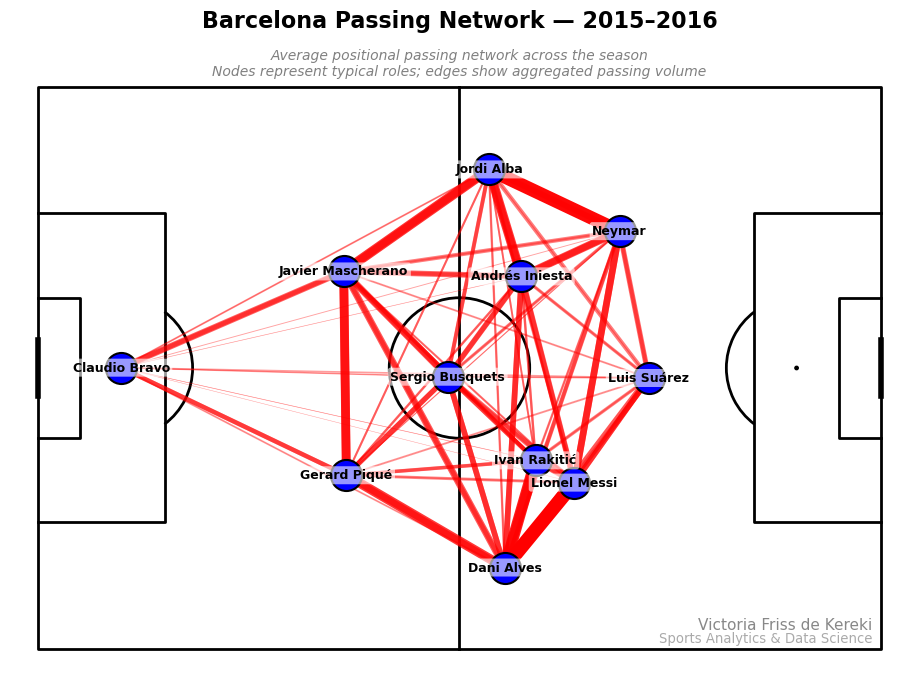

In [22]:
res = build_season_network(
    passes,
    sb,
    team="Barcelona",
    season="2015/2016"
)

if res:
    node_pos, links = res
    plot_season_network(node_pos, links, "Barcelona", "2015/2016")

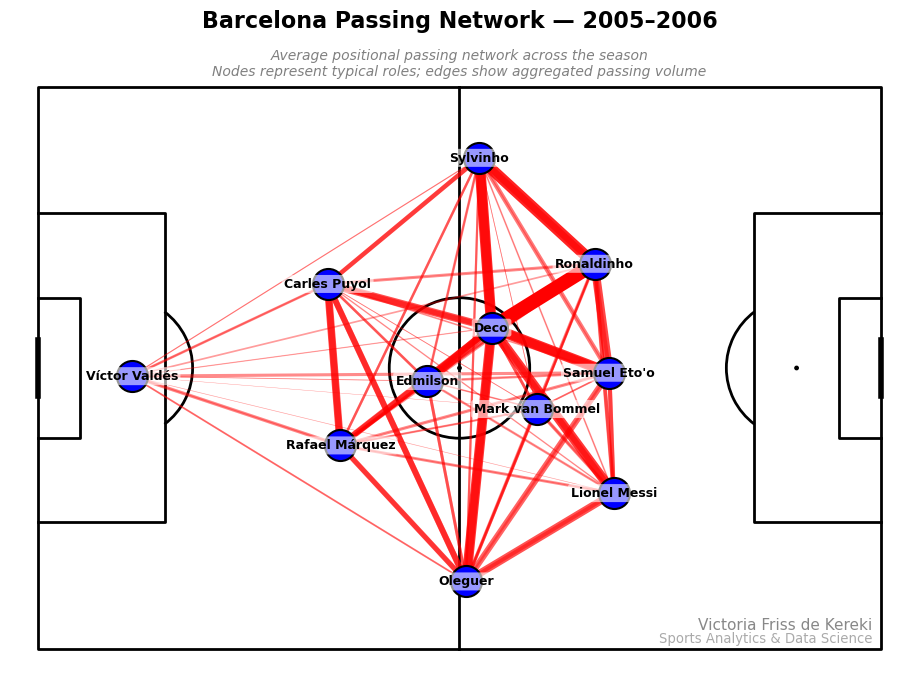

In [23]:
res = build_season_network(
    passes,
    sb,
    team="Barcelona",
    season="2005/2006"
)

if res:
    node_pos, links = res
    plot_season_network(node_pos, links, "Barcelona", "2005/2006")

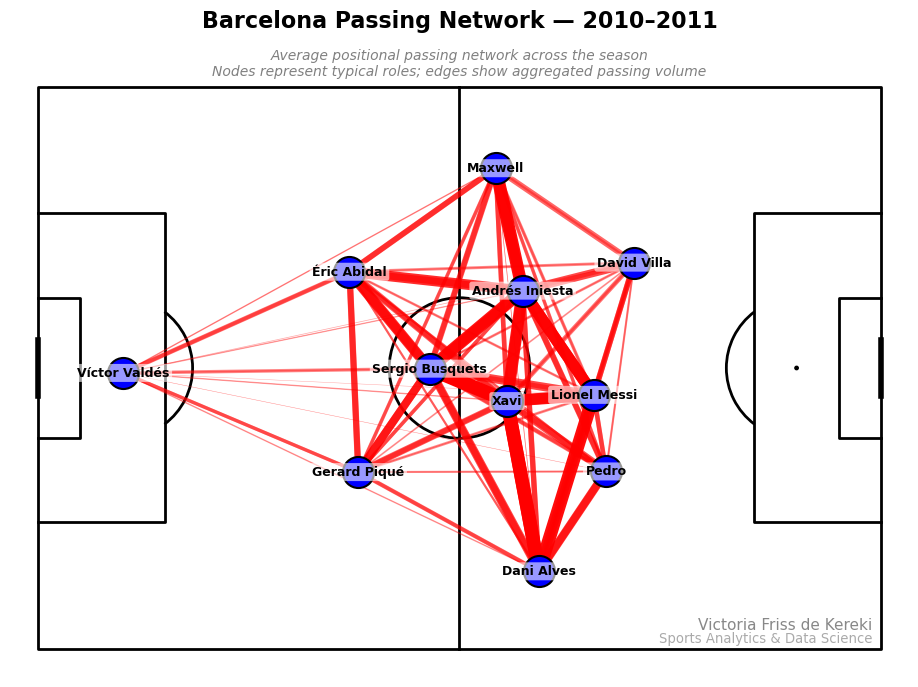

In [24]:
res = build_season_network(
    passes,
    sb,
    team="Barcelona",
    season="2010/2011"
)

if res:
    node_pos, links = res
    plot_season_network(node_pos, links, "Barcelona", "2010/2011")

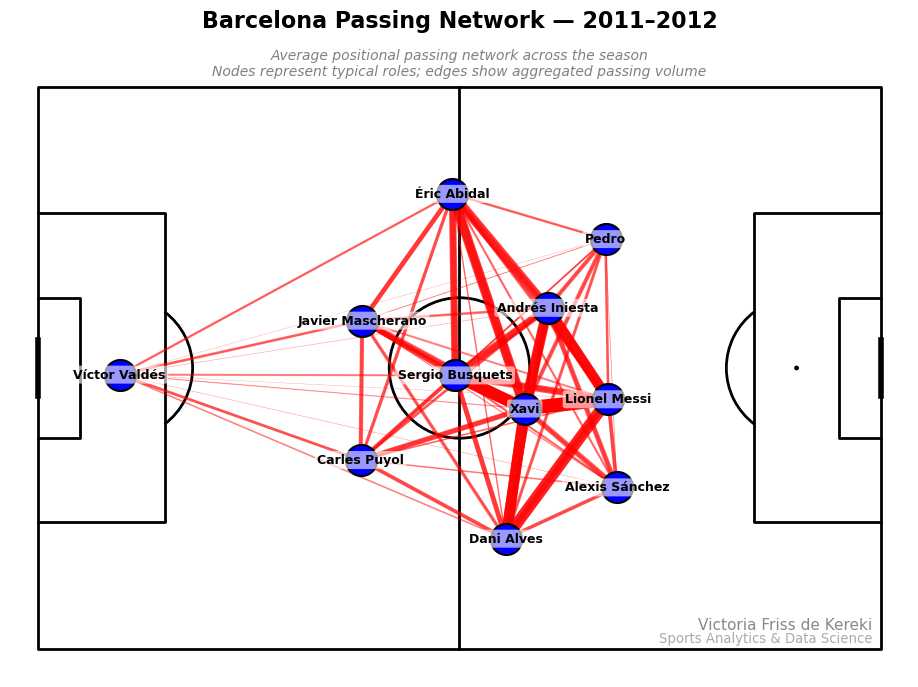

In [25]:
res = build_season_network(
    passes,
    sb,
    team="Barcelona",
    season="2011/2012"
)

if res:
    node_pos, links = res
    plot_season_network(node_pos, links, "Barcelona", "2011/2012")

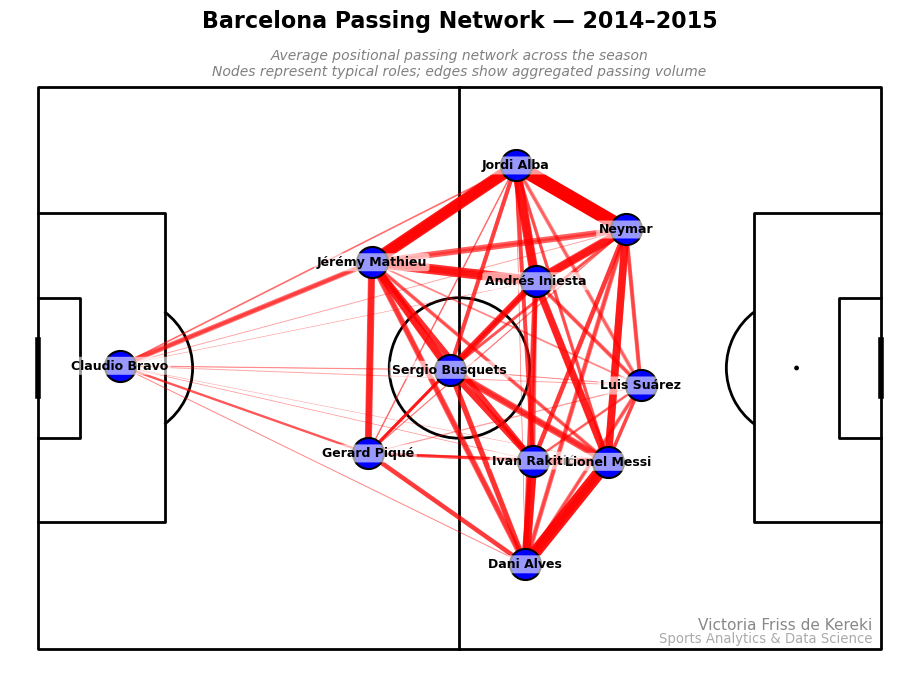

In [26]:
res = build_season_network(
    passes,
    sb,
    team="Barcelona",
    season="2014/2015"
)

if res:
    node_pos, links = res
    plot_season_network(node_pos, links, "Barcelona", "2014/2015")

In [27]:
plot_all_seasons_grid(
    passes,
    sb,
    team="Barcelona",
    n_cols=3
)

KeyboardInterrupt: 